### aim: create a figure for main model mask, and AMOC timeseries

    https://www.notion.so/joe-k-guest/How-I-calculate-the-AMOC-1d2c5ba6a23e806b8631fdca83480e20
    
### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### notebook footer

In [5]:
def nbf(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

In [6]:
sav = False
if sav:
    savenam = 'test2.nc'
    data_vars = {'vomecrty':(['time_counter', 'depthv', 'y', 'x'], vomecrty.values,
    {'units': 'µatm',
    'long_name':'Surface ocean pCO2'}),
    }
    # define coordinates
    coords = {'time_counter': (['time_counter'], time_counter),
            'time_centered': (['time_centered'], time_centered),
    'nav_lat': (['y','x'], nav_lat),
    'nav_lon': (['y','x'], nav_lon),
    'depthv': (['depthv'], depthv)}
    # define global attributes
    attrs = {'made in':'SOZONE/MEDUSA/makeYearlyMEDUSAsubsetfiles.ipynb',
    'desc': 'yearly medusa files, saving only variables of interest'
    }
    ds = xr.Dataset(data_vars=data_vars,
    coords=coords,
    attrs=attrs)
    ds.to_netcdf(savenam)

#### tylist

In [7]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

## load model IDs

In [8]:
import models
reload(models)
from models import MODELS as MD

keys = ['CCLIM', 'CCLIM2', 'HIST','HOSE']

for k in keys:
    tm = MD[k]['id']
    print(f'model {k} ({tm})')

model CCLIM (TOM12_TJ_LC51)
model CCLIM2 (TOM12_TJ_LC52)
model HIST (TOM12_TJ_LA50)
model HOSE (TOM12_TJ_LAH3)


## calculate AMOC

In [9]:
def make_AMOClist(yrst, yrend, tr, baseDir = '/gpfs/data/greenocean/software/resources/CDFTOOLS/MOCresults/'):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        tyr = yrs[i]
        ty = f'{baseDir}{tr}_1m_{tyr}0101*MOC.nc'
        t2 = glob.glob(ty)
        ylist.append(t2[0])
    return ylist

def get_max_amoc(moc_dataset):
    atl_at_26 = moc_dataset.zomsfatl.sel(y=94).squeeze()
    
    # Calculate max along the depth dimension
    max_atl = atl_at_26.max(dim=[d for d in atl_at_26.dims if d != 'time_counter'][0])
    
    # Rename to AMOC
    max_atl.name = 'AMOC'
    
    # Convert cftime to pandas datetime
    time_pd = pd.to_datetime([pd.Timestamp(t.isoformat()) for t in max_atl.time_counter.values])
    max_atl = max_atl.assign_coords(time_counter=time_pd)
    
    return max_atl

In [10]:
# Load all AMOC timeseries
AMOC = {
    key: get_max_amoc(xr.open_mfdataset(make_AMOClist(1940, 2020, MD[key]['id'])))
    for key in MD.keys()
}

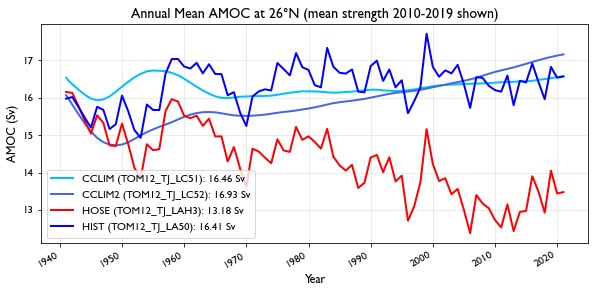

In [11]:
fact = 0.7
fig, ax = plt.subplots(figsize=(12*fact, 6*fact))

for key in AMOC.keys():
    # Resample to yearly average
    amoc_yearly = AMOC[key].resample(time_counter='1Y').mean()
    
    # Calculate mean for 2010-2019
    mean_2010s = amoc_yearly.sel(time_counter=slice('2010', '2019')).mean().values
    
    # Plot with color and label from MD
    rid = MD[key]['id']
    label = f'{key} ({rid}): {mean_2010s:.2f} Sv' 
    amoc_yearly.plot(ax=ax, color=MD[key]['color'], label=label, linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AMOC (Sv)', fontsize=12)
ax.set_title('Annual Mean AMOC at 26°N (mean strength 2010-2019 shown)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## region masks 

#### regrid step with CDO: 

    cdo remapnn,r360x180 mask_atl.nc mask_atl_rg.nc

In [12]:
ex = False
if ex:
    mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')
    atl = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/data/meshmask_with_Atl.nc')
    mask['HA'] = mask['ATL'].copy()
    mask['HA'].values = atl['NAH'][0,0,:,:].values
    mask['NA'] = mask['ATL'].copy()
    mask['NA'].values = mask['A1'][:,:].values + mask['A2'][:,:].values
    mask['AB'] = mask['ATL'].copy()
    
    # Adjust the masks
    # AB: everywhere AB == 1 OR HA == 1
    mask['AB'] = mask['AB'].copy()
    mask['AB'].values = ((mask['AB'] == 1) | (mask['HA'] == 1)).astype(int)
    # NA: where NA == 1 AND HA != 1
    mask['NA'] = mask['NA'].copy()
    mask['NA'].values = ((mask['NA'] == 1) & (mask['HA'] != 1)).astype(int)
    
    # Set nav_lon and nav_lat as coordinates
    mask = mask.set_coords(['nav_lon', 'nav_lat'])
    
    # Combine masks into a single dataset
    mask_dataset = xr.Dataset({
        'NA': mask['NA'],
        'HA': mask['HA'],
        'AB': mask['AB']
    })
    
    year = 1984
    tgrid = xr.open_dataset(f'/gpfs/data/greenocean/software/runs/TOM12_TJ_RVA0/ORCA2_1m_{year}0101_{year}1231_ptrc_T.nc')
    tgrid = tgrid[['DIC']].isel(time_counter=0, deptht=0)  # Keep as Dataset, select time and depth
    tgrid['NA'] = tgrid['DIC'].copy()
    tgrid['HA'] = tgrid['DIC'].copy()
    tgrid['AB'] = tgrid['DIC'].copy()
    tgrid['NA'].values = mask['NA'].values
    tgrid['HA'].values = mask['HA'].values
    tgrid['AB'].values = mask['AB'].values
    tgrid = tgrid.drop('DIC')
    
    # Add attribute
    tgrid.attrs['created_in'] = 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-mask.ipynb'
    
    # Save to NetCDF
    tgrid.to_netcdf('./data/mask_atl.nc')
    print("Mask saved to ./data/mask_atl.nc")

In [13]:
MA = xr.open_dataset('./data/mask_atl.nc')
MA_rg = xr.open_dataset('./data/mask_atl_rg.nc')

#### check that region masks look ok when regridded

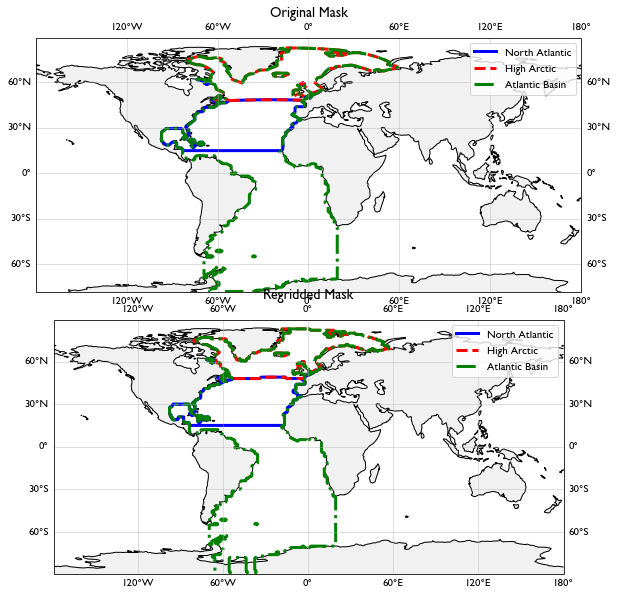

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define colors and line styles for each mask
colors = {'NA': 'blue', 'HA': 'red', 'AB': 'green'}
labels = {'NA': 'North Atlantic', 'HA': 'High Arctic', 'AB': 'Atlantic Basin'}
linestyles = {'NA': '-', 'HA': '--', 'AB': '-.'}

fig, axes = plt.subplots(2, 1, figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot original mask
ax = axes[0]
for key in ['NA', 'HA', 'AB']:
    CS = ax.contour(
        MA['nav_lon'],
        MA['nav_lat'],
        MA[key].values,
        levels=[0.5],
        colors=colors[key],
        linewidths=3,
        linestyles=linestyles[key],
        transform=ccrs.PlateCarree()
    )
    ax.plot([], [], color=colors[key], linewidth=3, linestyle=linestyles[key], label=labels[key])

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.gridlines(draw_labels=True, alpha=0.5)
ax.set_title('Original Mask', fontsize=14)
ax.legend(fontsize=11)

# Plot regridded mask
ax = axes[1]
for key in ['NA', 'HA', 'AB']:
    CS = ax.contour(
        MA_rg['lon'],
        MA_rg['lat'],
        MA_rg[key].values,
        levels=[0.5],
        colors=colors[key],
        linewidths=3,
        linestyles=linestyles[key],
        transform=ccrs.PlateCarree()
    )
    ax.plot([], [], color=colors[key], linewidth=3, linestyle=linestyles[key], label=labels[key])

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.gridlines(draw_labels=True, alpha=0.5)
ax.set_title('Regridded Mask', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## full fig 1

In [15]:
w = xr.open_dataset('/gpfs/data/greenocean/software/runs/clims/TOM12_RW_OBi1/ORCA2_1m_clim_2010_2019_diad_T_rg.nc')

tdat = w.PPINT.mean(dim = 'time')

In [16]:
# w2 = xr.open_dataset('/gpfs/data/greenocean/software/runs/TOM12_TJ_LA50/ORCA2_1m_20230101_20231231_diad_T.nc')
# w2.PPINT

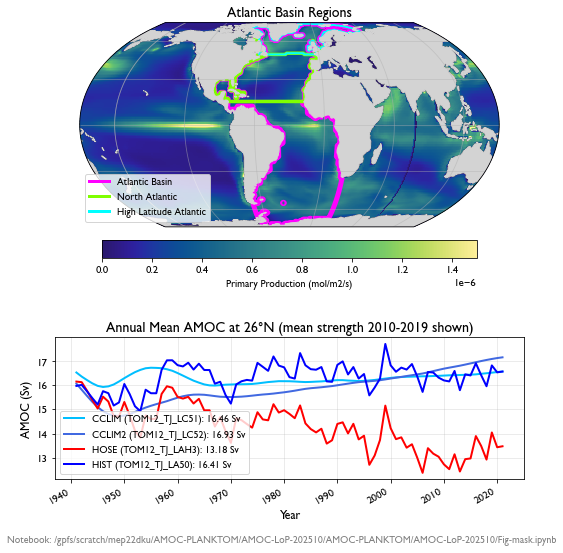

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cm

tcmap = jested_6  # prachovjezero_6
# Define colors and line styles for each mask
colors_mask = {'NA': 'chartreuse', 'HA': "aqua", 'AB': 'fuchsia'}
labels_mask = {'NA': 'North Atlantic', 'HA': 'High Latitude Atlantic', 'AB': 'Atlantic Basin'}
linewidths = {'NA': 3.5, 'HA': 2, 'AB': 5}
linestyles = {'NA': '-', 'HA': '-', 'AB': '-'}

# Set min and max for pcolormesh
vmin = 0  # Adjust as needed
vmax = 1.5e-6  # Adjust as needed

fact = 0.7
fig = plt.figure(figsize=(12*fact, 12*fact))
# Create gridspec for custom layout
gs = fig.add_gridspec(2, 1, height_ratios=[1.8, 1], hspace=0.3)

# Top panel: Map with Equal Earth projection centered on Atlantic
ax0 = fig.add_subplot(gs[0], projection=ccrs.EqualEarth(central_longitude=-30))

# Add pcolormesh
pcm = ax0.pcolormesh(
    tdat.lon,
    tdat.lat,
    tdat.values,
    cmap=cm.haline,
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# Add horizontal colorbar
cbar = plt.colorbar(pcm, ax=ax0, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('Primary Production (mol/m2/s)', fontsize=10)

for key in ['AB','NA', 'HA']:
    CS = ax0.contour(
        MA_rg['lon'],
        MA_rg['lat'],
        MA_rg[key].values,
        levels=[0.5],
        colors=colors_mask[key],
        linewidths=linewidths[key],
        linestyles=linestyles[key],
        transform=ccrs.PlateCarree()
    )
    ax0.plot([], [], color=colors_mask[key], linewidth=3, linestyle=linestyles[key], label=labels_mask[key])

ax0.coastlines()
ax0.add_feature(cfeature.LAND, facecolor='lightgray', alpha=1, zorder = 2)
ax0.gridlines(alpha=0.5)
ax0.set_global()  # Show the whole globe
ax0.set_title('Atlantic Basin Regions', fontsize=14)
ax0.legend(fontsize=10, loc='lower left')

# Bottom panel: AMOC timeseries
ax1 = fig.add_subplot(gs[1])
for key in AMOC.keys():
    # Resample to yearly average
    amoc_yearly = AMOC[key].resample(time_counter='1Y').mean()
    
    # Calculate mean for 2010-2019
    mean_2010s = amoc_yearly.sel(time_counter=slice('2010', '2019')).mean().values
    
    # Plot with color and label from MD
    rid = MD[key]['id']
    label = f'{key} ({rid}): {mean_2010s:.2f} Sv' 
    amoc_yearly.plot(ax=ax1, color=MD[key]['color'], label=label, linewidth=2)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('AMOC (Sv)', fontsize=12)
ax1.set_title('Annual Mean AMOC at 26°N (mean strength 2010-2019 shown)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
nbf(fig, 'AMOC-PLANKTOM/AMOC-LoP-202510/Fig-mask.ipynb', path_y_position=0.02)

plt.tight_layout()
plt.savefig('./plts/fig_masks.png', dpi=300, bbox_inches='tight')
plt.show()